In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px 
from collections import Counter 
from itertools import combinations 
from scipy.cluster.vq import kmeans,vq 
df=pd.read_csv(r"C:\Users\RISHABH SINGH\Desktop\INTERNSHALA\PROJECT FILES\MACHINE LEARNING\Flipkart.csv")

In [2]:
df.head(5)

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/11 11:09:33 PM GMT+5:30,65,Prefer not to say,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,Yes,Rarely,Filter,First page,1,...,Yes,Rarely,Sometimes,1,Sometimes,1,1,All the above,Add more familiar brands to the list,949456
1,2023/06/07 6:17:42 PM GMT+5:30,45,Male,Less than once a month,Clothing and Fashion,Sometimes,Multiple times a day,categories,First page,3,...,Yes,Moderately,Yes,5,Sometimes,2,4,User-friendly website/app interface,No problems with Amazon,255226
2,2023/06/09 3:25:33 PM GMT+5:30,31,Prefer not to say,Once a month,Beauty and Personal Care,No,Rarely,categories,Multiple pages,1,...,Yes,Moderately,No,1,No,3,4,.,Nil,257992
3,2023/06/12 2:43:30 PM GMT+5:30,14,Female,Multiple times a week,Beauty and Personal Care;Home and Kitchen,Yes,Few times a week,Filter,Multiple pages,3,...,No,Occasionally,Yes,5,Sometimes,2,5,All the above,Product quality and accuracy,252263
4,2023/06/08 5:33:01 PM GMT+5:30,36,Prefer not to say,Less than once a month,Beauty and Personal Care;others,No,Few times a month,NaN,Multiple pages,2,...,No,Moderately,Sometimes,1,No,5,1,Wide product selection,Nothing,982763


In [79]:
df.to_csv(r"C:\Users\RISHABH SINGH\Desktop\INTERNSHALA\PROJECT FILES\MACHINE LEARNING\Flipkart.csv",index=False)

In [3]:
df.shape,df.size,df.isnull().sum()

((800, 24),
 19200,
 Timestamp                                   0
 age                                         0
 Gender                                      0
 Purchase_Frequency                          0
 Purchase_Categories                         0
 Personalized_Recommendation_Frequency       0
 Browsing_Frequency                          0
 Product_Search_Method                     162
 Search_Result_Exploration                   0
 Customer_Reviews_Importance                 0
 Add_to_Cart_Browsing                        0
 Cart_Completion_Frequency                   0
 Cart_Abandonment_Factors                    0
 Saveforlater_Frequency                      0
 Review_Left                                 0
 Review_Reliability                          0
 Review_Helpfulness                          0
 Personalized_Recommendation_Frequency       0
 Recommendation_Helpfulness                  0
 Rating_Accuracy                             0
 Shopping_Satisfaction                  

In [4]:
#Task-1 Data cleaning & preparation 
#Sub_Task-1-Remove duplicate columns and Rename some of them
df.columns=df.columns.str.strip()

In [5]:
df.columns.duplicated()



array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False])

In [6]:
df=df.loc[:,~df.columns.duplicated()] #As we know loc is label based selection. The symbol of negation '~' inverts all the boolean values and makes the 'True' as 'False' and masking selects only the 'True' value


In [7]:
df.columns=[{'age':'Age','transaction':'Transaction'}.get(col,col) for col in df.columns]

In [8]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Recommendation_Helpfulness', 'Rating_Accuracy',
       'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas',
       'Transaction'],
      dtype='object')

In [9]:
#Sub_Task-2-Standardise Categorical Columns: (for e.g. Gender,Frequency Levels,Recommendation Responses )
df['Gender']=df['Gender'].str.strip().str.title().replace({'Prefer not to say':'Prefer Not To Say','Others':'Other'})
df['Purchase_Frequency']=df['Purchase_Frequency'].str.strip().str.title()
df['Purchase_Categories']=df['Purchase_Categories'].str.strip() 


In [10]:
df[['Gender','Purchase_Frequency','Purchase_Categories']]

,Gender,Purchase_Frequency,Purchase_Categories
0,Prefer Not To Say,Few Times A Month,Groceries and Gourmet Food;Beauty and Personal...
1,Male,Less Than Once A Month,Clothing and Fashion
2,Prefer Not To Say,Once A Month,Beauty and Personal Care
3,Female,Multiple Times A Week,Beauty and Personal Care;Home and Kitchen
4,Prefer Not To Say,Less Than Once A Month,Beauty and Personal Care;others
...,...,...,...
795,Prefer Not To Say,Few Times A Month,Groceries and Gourmet Food;Beauty and Personal...
796,Prefer Not To Say,Once A Week,Clothing and Fashion
797,Prefer Not To Say,Once A Month,Groceries and Gourmet Food;Beauty and Personal...
798,Other,Few Times A Month,Groceries and Gourmet Food;Beauty and Personal...


In [11]:
#Sub_Task-3:Handled the missing value in 'Product_Search_Method' 
df['Product_Search_Method']=df['Product_Search_Method'].fillna('Not Appeared')

In [12]:
df['Product_Search_Method']

0            Filter
1        categories
2        categories
3            Filter
4      Not Appeared
           ...     
795          Filter
796         Keyword
797      categories
798         Keyword
799      categories
Name: Product_Search_Method, Length: 800, dtype: object

In [13]:
#Sub_Task-4-Standardised the numerical columns to make them usable in calculations 

Numeric_columns=['Age','Customer_Reviews_Importance','Rating_Accuracy','Shopping_Satisfaction','Transaction']
for col in Numeric_columns:
    df[col]=df[col].apply(pd.to_numeric,errors='coerce')

In [14]:
df.dtypes

Timestamp                                object
Age                                       int64
Gender                                   object
Purchase_Frequency                       object
Purchase_Categories                      object
Personalized_Recommendation_Frequency    object
Browsing_Frequency                       object
Product_Search_Method                    object
Search_Result_Exploration                object
Customer_Reviews_Importance               int64
Add_to_Cart_Browsing                     object
Cart_Completion_Frequency                object
Cart_Abandonment_Factors                 object
Saveforlater_Frequency                   object
Review_Left                              object
Review_Reliability                       object
Review_Helpfulness                       object
Recommendation_Helpfulness               object
Rating_Accuracy                           int64
Shopping_Satisfaction                     int64
Service_Appreciation                    

In [20]:
#Sub_Task-5-Binned the 'Age' into 'Age-categories' for better classification 

df.insert(2,'Age_Group',pd.cut(df['Age'],bins=[3,18,45,67],labels=['Child+Young','Adult','Senior'],include_lowest=True))


In [21]:
df['Age_Group']

0           Senior
1            Adult
2            Adult
3      Child+Young
4            Adult
          ...     
795          Adult
796    Child+Young
797         Senior
798    Child+Young
799         Senior
Name: Age_Group, Length: 800, dtype: category
Categories (3, object): ['Child+Young' < 'Adult' < 'Senior']

In [22]:
#Sub_Task-6-Basket-list for market basket analysis 
df['Purchase_Categories']=df['Purchase_Categories'].astype(str)
df['Categories_List']=df['Purchase_Categories'].apply(lambda x:[cat.strip() for cat in str(x).split(';') if cat.strip() and cat.lower() !='nan'])

In [23]:
df['Categories_List'].head(5)  

0    [Groceries and Gourmet Food, Beauty and Person...
1                               [Clothing and Fashion]
2                           [Beauty and Personal Care]
3         [Beauty and Personal Care, Home and Kitchen]
4                   [Beauty and Personal Care, others]
Name: Categories_List, dtype: object

In [24]:
df.insert(5,'Categories_List',df.pop('Categories_List'))

In [25]:
#Task 2: Descriptive Behavior Analysis 
#Sub_Task-1-#Customer_Demographics 

print(f"Age_Description:\n{df['Age'].describe()}\nGroup_Description:\n{df['Age_Group'].describe()}")

df['Gender'].value_counts(normalize=True).to_frame().style.format("{:.2%}").background_gradient(cmap='PuBu')


Age_Description:
count    800.0000
mean      35.2750
std       18.7481
min        3.0000
25%       18.0000
50%       36.0000
75%       52.0000
max       67.0000
Name: Age, dtype: float64
Group_Description:
count       800
unique        3
top       Adult
freq        319
Name: Age_Group, dtype: object


,proportion
Gender,
Other,28.00%
Prefer Not To Say,25.37%
Female,23.62%
Male,23.00%


In [26]:
#Sub_Task-2-Analyze purchase frequency and purchase categories  

df['Purchase_Frequency'].value_counts(normalize=True).to_frame().style.format("{:.2%}").background_gradient(cmap='YlGn')

,proportion
Purchase_Frequency,
Less Than Once A Month,21.12%
Once A Month,20.25%
Few Times A Month,19.75%
Multiple Times A Week,19.50%
Once A Week,19.38%


In [29]:
all_categories = [sublist for sublist in df['Categories_List']]
cat_counts = Counter([item for sublist in all_categories for item in sublist])
print("Top categories:", cat_counts.most_common(5))

Top categories: [('Clothing and Fashion', 436), ('Beauty and Personal Care', 423), ('Home and Kitchen', 418), ('others', 380), ('Groceries and Gourmet Food', 377)]


In [30]:
print("Products_Distribution:")
df['Purchase_Categories'].value_counts(normalize=True).to_frame().style.format("{:.2%}").background_gradient(cmap='viridis')

Products_Distribution:


,proportion
Purchase_Categories,
Groceries and Gourmet Food;Beauty and Personal Care;Home and Kitchen,5.25%
Clothing and Fashion,5.00%
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others,4.25%
Beauty and Personal Care;Clothing and Fashion;Home and Kitchen,4.25%
Beauty and Personal Care;others,4.25%
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion,4.00%
others,4.00%
Home and Kitchen,3.75%
Beauty and Personal Care;Clothing and Fashion,3.75%


In [31]:
#Sub_Task-3-Identify top browsing methods and most common cart abandonment factors 

df['Product_Search_Method'].value_counts().to_frame().style.highlight_max(color='Blue')

,count
Product_Search_Method,
categories,168
Not Appeared,162
others,161
Keyword,157
Filter,152


In [32]:
df['Cart_Abandonment_Factors'].value_counts().to_frame().style.background_gradient(cmap='magma')

,count
Cart_Abandonment_Factors,
others,209
Found a better price elsewhere,207
Changed my mind or no longer need the item,193
High shipping costs,191


In [33]:
#Sub_Task-4-Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy. 

Tagging_Recommendations={'Yes':3,'Sometimes':2,'No':1} #Recommendation_Helpfulness is a categorical column so we need to map it's values into number  

df.insert(20,'Recommendation_Helpfulness_Numeric',df['Recommendation_Helpfulness'].map(Tagging_Recommendations)) #Inserted the other numeric column beside it by using insert method

Stat_Cols=['Shopping_Satisfaction','Recommendation_Helpfulness_Numeric','Rating_Accuracy']
for col in Stat_Cols:
    Mean_Values=df[col].mean()
    Median_Values=df[col].median()
    print(f"{col:35} Mean-> {Mean_Values:.2f}      |    Median-> {Median_Values:.2f}")


Shopping_Satisfaction               Mean-> 3.07      |    Median-> 3.00
Recommendation_Helpfulness_Numeric  Mean-> 2.01      |    Median-> 2.00
Rating_Accuracy                     Mean-> 3.14      |    Median-> 3.00


In [34]:
#Sub_Task-5-Generate summary statistics and visualisations for key behavioural variables.

Behavioural_Drivers=df[['Purchase_Frequency','Purchase_Categories','Browsing_Frequency','Product_Search_Method','Add_to_Cart_Browsing',
                        'Cart_Completion_Frequency','Cart_Abandonment_Factors','Review_Left','Review_Reliability','Review_Helpfulness',
                        'Recommendation_Helpfulness','Shopping_Satisfaction']].describe(include='all')
print(Behavioural_Drivers)

            Purchase_Frequency  \
count                      800   
unique                       5   
top     Less Than Once A Month   
freq                       169   
mean                       NaN   
std                        NaN   
min                        NaN   
25%                        NaN   
50%                        NaN   
75%                        NaN   
max                        NaN   

                                      Purchase_Categories Browsing_Frequency  \
count                                                 800                800   
unique                                                 29                  4   
top     Groceries and Gourmet Food;Beauty and Personal...   Few times a week   
freq                                                   42                210   
mean                                                  NaN                NaN   
std                                                   NaN                NaN   
min                            

In [35]:
pd.crosstab(index=df['Purchase_Frequency'], columns=df['Browsing_Frequency'])

Browsing_Frequency,Few times a month,Few times a week,Multiple times a day,Rarely
Purchase_Frequency,,,,
Few Times A Month,42,44,43,29
Less Than Once A Month,42,44,30,53
Multiple Times A Week,29,41,42,44
Once A Month,41,36,46,39
Once A Week,36,45,36,38


In [36]:
#Visualizations  
df_numeric=df.copy()
freq_num={'Less Than Once A Month':1,'Once A Month':2,'Few Times A Month':3,'Once A Week':4,'Multiple Times A Week':5}
freq_num_bf={'Rarely':1,'Few times a month':2,'Few times a week':3,'Multiple times a day':4}
df_numeric['Purchase_Frequency_Num']=df['Purchase_Frequency'].map(freq_num)
df_numeric['Browsing_Frequency_Num']=df['Browsing_Frequency'].map(freq_num_bf)

numeric_cols=['Purchase_Frequency_Num','Browsing_Frequency_Num','Recommendation_Helpfulness_Numeric','Shopping_Satisfaction']



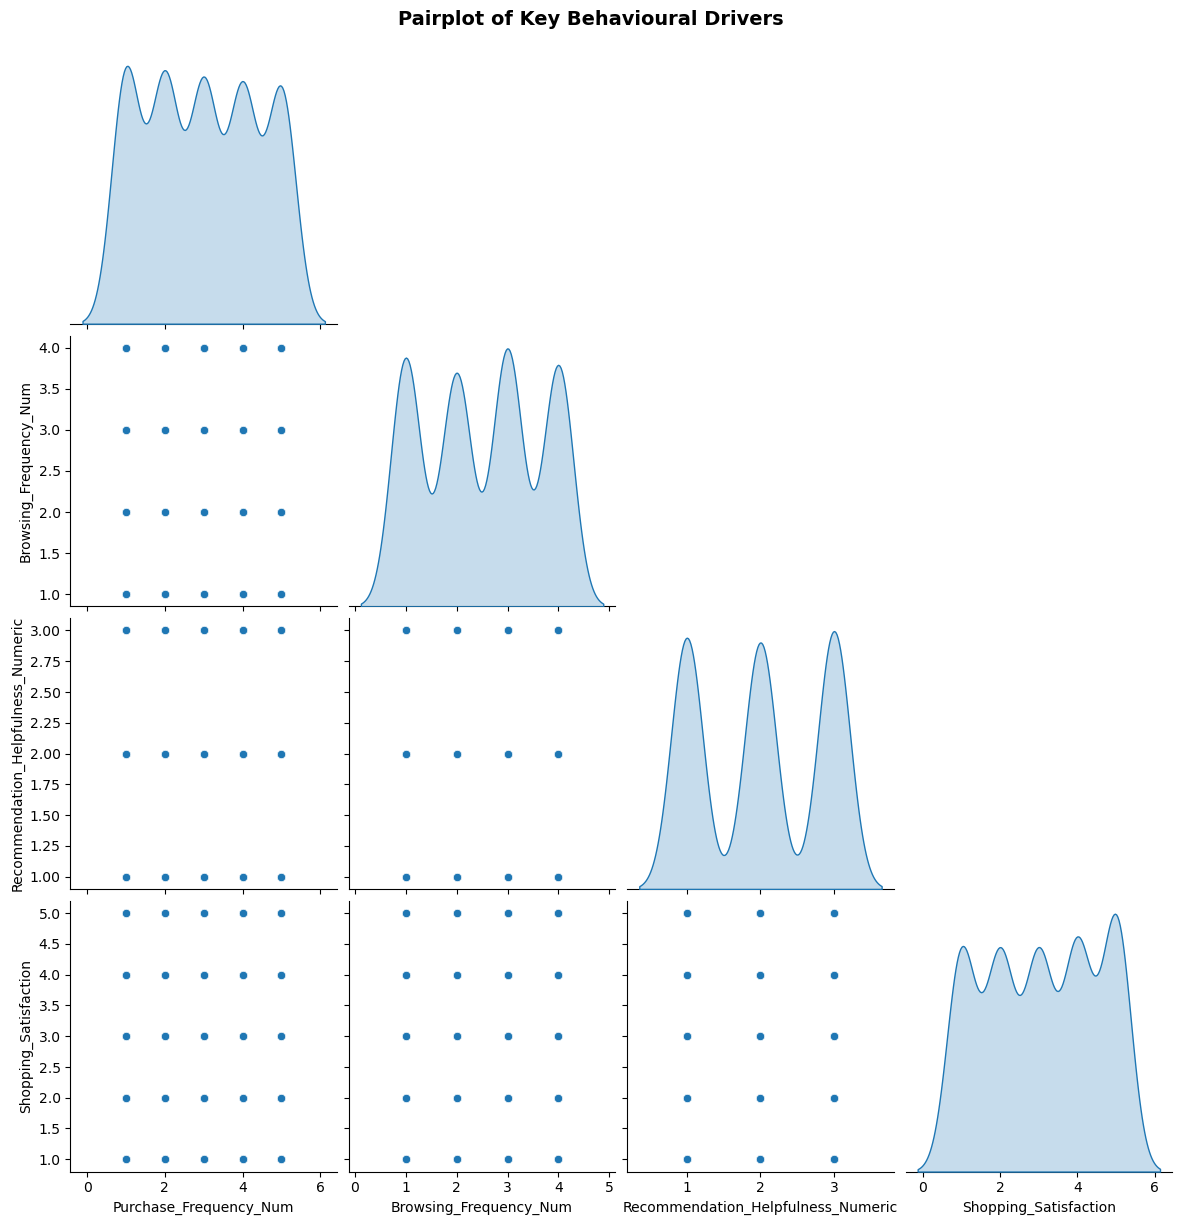

In [37]:
#1.Pairplot 
a=sns.pairplot(df_numeric[numeric_cols],diag_kind='kde',height=3,corner=True)
a.fig.suptitle('Pairplot of Key Behavioural Drivers',y=1.02,fontsize=14,fontweight='bold')
plt.savefig('Pairplot of Key Behavioural Drivers.png',dpi=300,bbox_inches='tight')
plt.show()


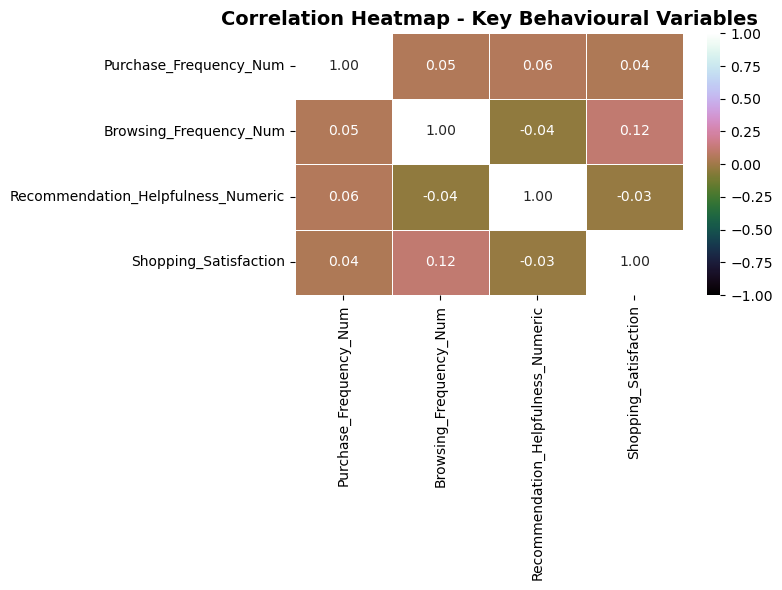

In [38]:
#2.Heat-Map 
plt.figure(figsize=(8,6))
sns.heatmap(df_numeric[numeric_cols].corr(), annot=True, cmap='cubehelix', vmin=-1, vmax=1, linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap - Key Behavioural Variables', fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('Key_Behavioural_Heatmap.png',dpi=300,bbox_inches='tight')
plt.show()

C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_4668\3112480892.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,y='Purchase_Frequency',order=df['Purchase_Frequency'].value_counts().index,palette='YlGn')


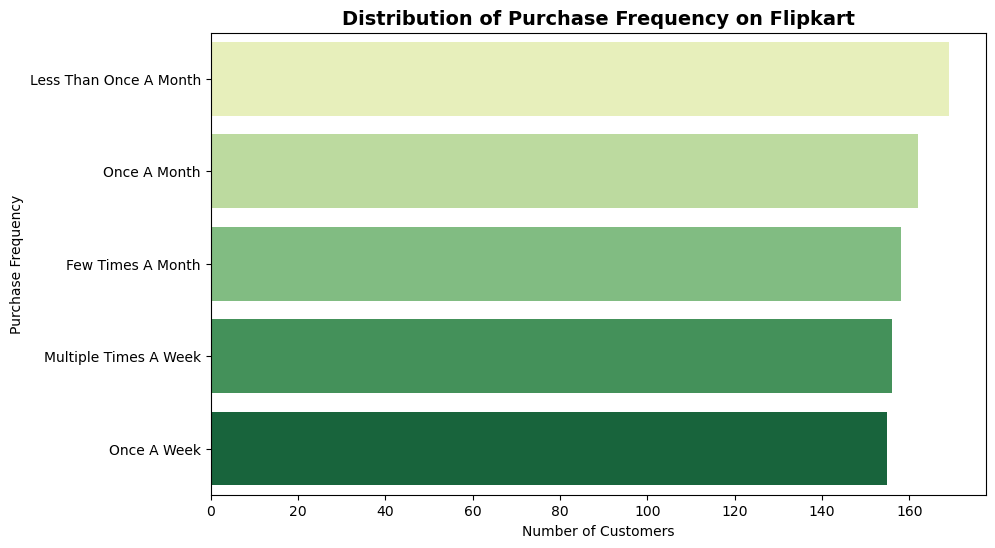

In [41]:
#3.Countplot-Purchase_Frequency
plt.figure(figsize=(10,6))
sns.countplot(data=df,y='Purchase_Frequency',order=df['Purchase_Frequency'].value_counts().index,palette='YlGn')
plt.title('Distribution of Purchase Frequency on Flipkart', fontsize=14,fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Purchase Frequency')
plt.savefig('Distribution of Purchase Frequency.png',dpi=300,bbox_inches='tight')
plt.show()


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_4668\819446018.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,y='Browsing_Frequency',order=df['Browsing_Frequency'].value_counts().index,palette='viridis')


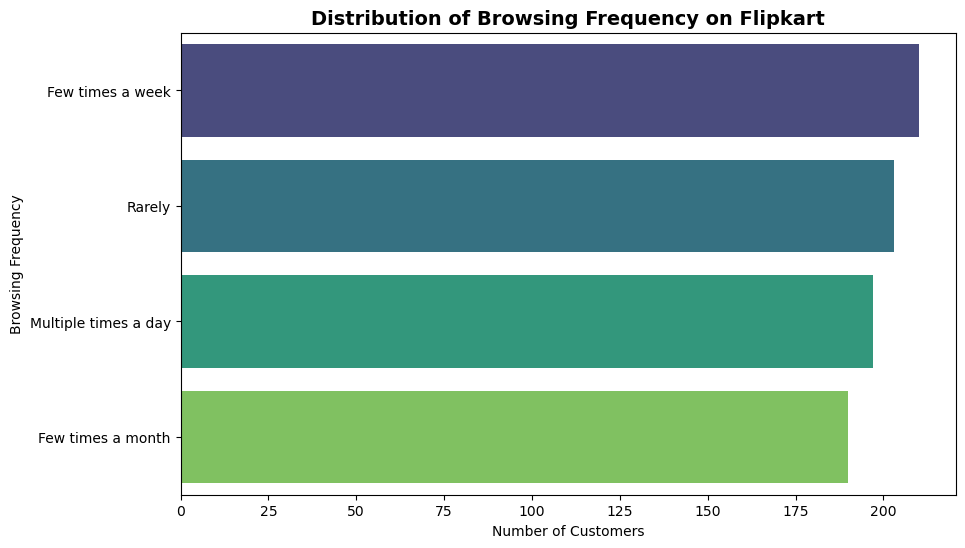

In [42]:
#3.Countplot-Browsing_Frequency
plt.figure(figsize=(10,6))
sns.countplot(data=df,y='Browsing_Frequency',order=df['Browsing_Frequency'].value_counts().index,palette='viridis')
plt.title('Distribution of Browsing Frequency on Flipkart', fontsize=14,fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Browsing Frequency')
plt.savefig('Distribution of Browsing Frequency.png',dpi=300,bbox_inches='tight')
plt.show()


In [43]:
#Task-3-Customer Segmentation and Profiling 
df[['Purchase_Frequency','Shopping_Satisfaction']]

,Purchase_Frequency,Shopping_Satisfaction
0,Few Times A Month,1
1,Less Than Once A Month,4
2,Once A Month,4
3,Multiple Times A Week,5
4,Less Than Once A Month,1
...,...,...
795,Few Times A Month,3
796,Once A Week,4
797,Once A Month,3
798,Few Times A Month,4


In [44]:
#Sub_Task-1-Segmenting customers into groups based on purchasing frequency 
freq_map={'Less Than Once A Month':1,'Once A Month':2,'Few Times A Month':3,'Once A Week':4,'Multiple Times A Week':5}
df['Purchase_Frequency_numeric']=df['Purchase_Frequency'].map(freq_map)
def create_segment(row):
    freq = row['Purchase_Frequency_numeric']
    sats = row['Shopping_Satisfaction']
    if freq >= 4 and sats >= 4:
        return 'Frequent Buyers'
    elif freq >= 3 and sats >= 3:
        return 'Occasional Shoppers'
    else:
        return 'At-Risk Customers'

df['Segment'] = df.apply(create_segment, axis=1)

In [45]:
df['Segment']

0        At-Risk Customers
1        At-Risk Customers
2        At-Risk Customers
3          Frequent Buyers
4        At-Risk Customers
              ...         
795    Occasional Shoppers
796        Frequent Buyers
797      At-Risk Customers
798    Occasional Shoppers
799      At-Risk Customers
Name: Segment, Length: 800, dtype: object

In [46]:
#Sub_Task-2-Analyze demographic or behavioral differences across these segments.
# Profiling of Segments

Profile=df.groupby('Segment').agg({'Purchase_Frequency_numeric':['mean','count'],
                                   'Shopping_Satisfaction':['mean'],
                                   'Age':['mean'],
                                   'Recommendation_Helpfulness_Numeric':['mean']}).round(2)

Profile.columns = ['Avg_Frequency_Score', 'Customer_Count', 'Avg_Satisfaction', 
                   'Avg_Age', 'Avg_Rec_Helpfulness']
print(Profile) 


                     Avg_Frequency_Score  Customer_Count  Avg_Satisfaction  \
Segment                                                                      
At-Risk Customers                   2.36             507              2.48   
Frequent Buyers                     4.49             136              4.55   
Occasional Shoppers                 3.58             157              3.66   

                     Avg_Age  Avg_Rec_Helpfulness  
Segment                                            
At-Risk Customers      35.55                 2.01  
Frequent Buyers        35.21                 2.00  
Occasional Shoppers    34.43                 2.01  


In [47]:
#Sub-Task-3-K-Means Clustering 

features=df[['Purchase_Frequency_numeric','Shopping_Satisfaction','Recommendation_Helpfulness_Numeric','Age']].dropna()

#Run K-Means 
centroids,_=kmeans(features.values.astype(float),3)
idx,_=vq(features.values.astype(float),centroids)
df.loc[features.index,'Cluster']=idx.astype(int)

# Map clusters to meaningful names 
cluster_names={0:'Frequent Buyers',1:'Occasional Shoppers',2:'At-Risk Customers'}
df['Cluster_Name']=df['Cluster'].map(cluster_names)

#K-Means Cluster Profiles 
kmeans_profile=df.groupby('Cluster_Name').agg({
'Purchase_Frequency_numeric':'mean',          
'Shopping_Satisfaction':'mean',
'Age':'mean',
'Recommendation_Helpfulness_Numeric':'mean',
'Cluster':'count'}).round(2)
print(kmeans_profile)








                     Purchase_Frequency_numeric  Shopping_Satisfaction    Age  \
Cluster_Name                                                                    
At-Risk Customers                          2.90                   2.96  34.77   
Frequent Buyers                            2.92                   3.14  56.32   
Occasional Shoppers                        3.06                   3.10  12.95   

                     Recommendation_Helpfulness_Numeric  Cluster  
Cluster_Name                                                      
At-Risk Customers                                  2.05      266  
Frequent Buyers                                    1.97      278  
Occasional Shoppers                                2.02      256  


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_4668\816819129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,y='Segment',order=['Frequent Buyers','Occasional Shoppers','At-Risk Customers'],palette='viridis')
C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_4668\816819129.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Segment',y='Shopping_Satisfaction',showmeans=True,palette='cubehelix')


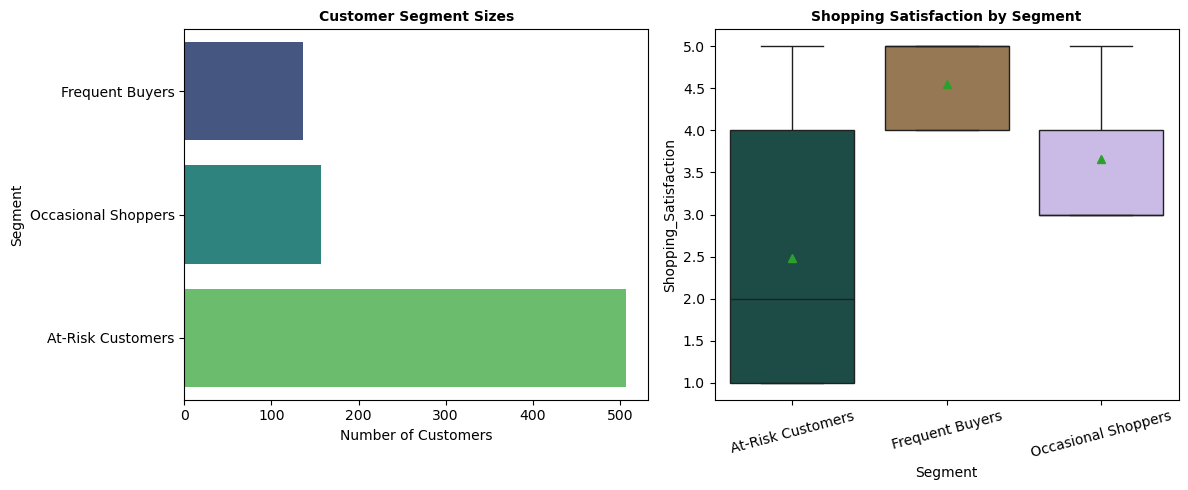

In [48]:
#Visualisations-Segments and Clusters
plt.figure(figsize=(12,5))
#Bar Chart-Segment Size 
plt.subplot(1,2,1)
sns.countplot(data=df,y='Segment',order=['Frequent Buyers','Occasional Shoppers','At-Risk Customers'],palette='viridis')
plt.title('Customer Segment Sizes',fontsize=10,fontweight='bold')
plt.xlabel('Number of Customers')
plt.savefig('Segment Size.png',dpi=300,bbox_inches='tight')

#Boxplot-Satisfaction by Segment 
plt.subplot(1,2,2)
sns.boxplot(data=df,x='Segment',y='Shopping_Satisfaction',showmeans=True,palette='cubehelix')
plt.title('Shopping Satisfaction by Segment',fontsize=10,fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('Distribution of Segments.png',dpi=300,bbox_inches='tight')
plt.show()


In [49]:
#Task-4-Recommendation and Review Insights

#Sub_Task-1-Relationship between recommendation helpfulness and shopping satisfaction. 

pd.crosstab(df['Recommendation_Helpfulness'],df['Shopping_Satisfaction'],normalize='index',margins=True).style.format("{:.2%}").background_gradient(cmap='cubehelix')

Shopping_Satisfaction,1,2,3,4,5
Recommendation_Helpfulness,,,,,
No,17.67%,20.30%,15.79%,21.80%,24.44%
Sometimes,21.84%,17.62%,22.99%,13.79%,23.75%
Yes,19.41%,19.05%,18.32%,23.81%,19.41%
All,19.62%,19.00%,19.00%,19.88%,22.50%


Review_Reliability_Num    0.011
Review_Helpfulness_Num   -0.035
Rating_Accuracy           1.000
Name: Rating_Accuracy, dtype: float64


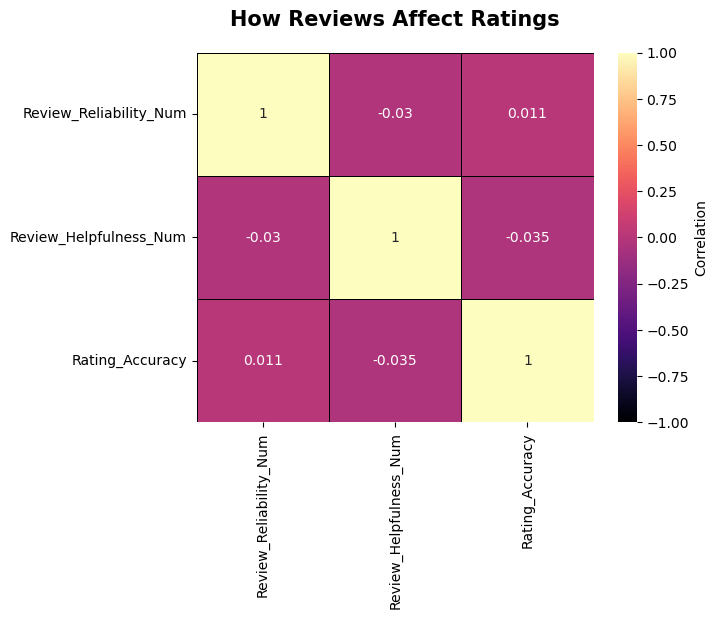

In [ ]:
#Sub-Task-2-Impact of Review Reliability,Review Helpfulness and Rating Accuracy

#Convert text into numbers
freq_rev_reli={'Never':0,'Rarely':1,'Occasionally':2,'Moderately':3,'Heavily':4}
freq_rev_help={'No':0,'Sometimes':1,'Yes':2}
df['Review_Reliability_Num']=df['Review_Reliability'].map(freq_rev_reli)
df['Review_Helpfulness_Num']=df['Review_Helpfulness'].map(freq_rev_help)

#Correlate with Rating Accuracy 
correl=df[['Review_Reliability_Num','Review_Helpfulness_Num','Rating_Accuracy']].corr()['Rating_Accuracy']
print(correl.round(3))

#Heatmap for better insight 
sns.heatmap(data=df[['Review_Reliability_Num','Review_Helpfulness_Num','Rating_Accuracy']].corr(),annot=True,cmap='magma',linewidths=0.7,linecolor='black',
            vmin=-1,vmax=1,cbar=True,cbar_kws={'label':'Correlation'})
plt.title('How Reviews Affect Ratings',y=1.05,fontsize=15,fontweight='bold')
plt.savefig('Reviews Affect Ratings Heatmap',dpi=300,bbox_inches='tight')
plt.show()

In [53]:
#Sub_Task-3-Trust in Recommendations
df['Recommendation_Helpfulness'].value_counts(normalize=True).to_frame().style.format('{:.2%}').background_gradient(cmap='gnuplot')

,proportion
Recommendation_Helpfulness,
Yes,34.12%
No,33.25%
Sometimes,32.62%


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_4668\3733204079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  x=sns.countplot(data=df, x='Recommendation_Helpfulness', order=['No', 'Sometimes', 'Yes'], palette='rainbow')


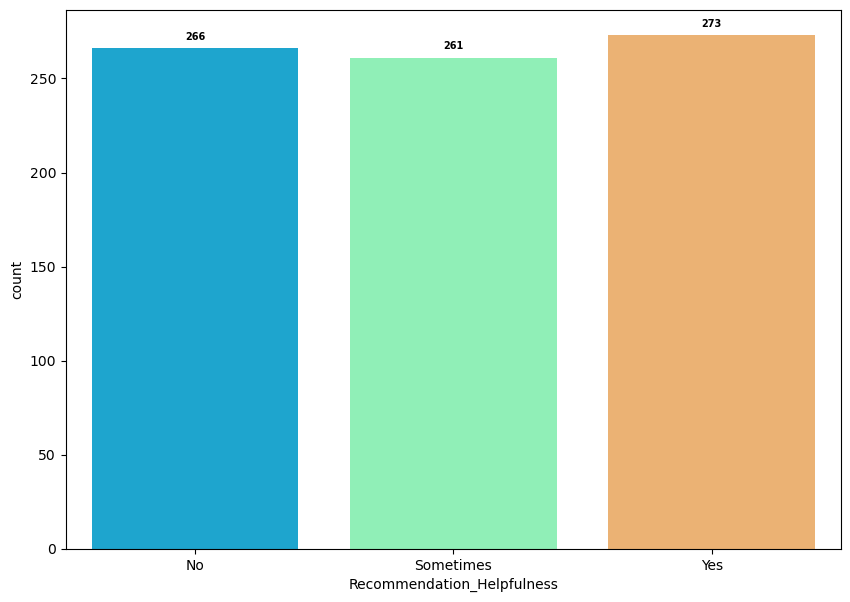

In [54]:
#Visual 
plt.figure(figsize=(10, 7))
x=sns.countplot(data=df, x='Recommendation_Helpfulness', order=['No', 'Sometimes', 'Yes'], palette='rainbow')
for container in x.containers:
    x.bar_label(container,padding=5,fontsize=7,fontweight='bold') 
plt.savefig('Recommend Helpful Count.png',dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
#Sub_Tak-4:Actionable Insights:

#Actionable: 
#Customers who find personalized recommendations helpful have significantly higher Shopping Satisfaction.
#Review Reliability and Review Helpfulness show positive correlation with Rating Accuracy (customers trust real reviews more than recommendations).
#Only ~40% of customers find Flipkart’s recommendations “highly helpful”.


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_4668\4180652320.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  y=sns.barplot(y=category_counts.index, x=category_counts.values, palette='gnuplot', orient='h')


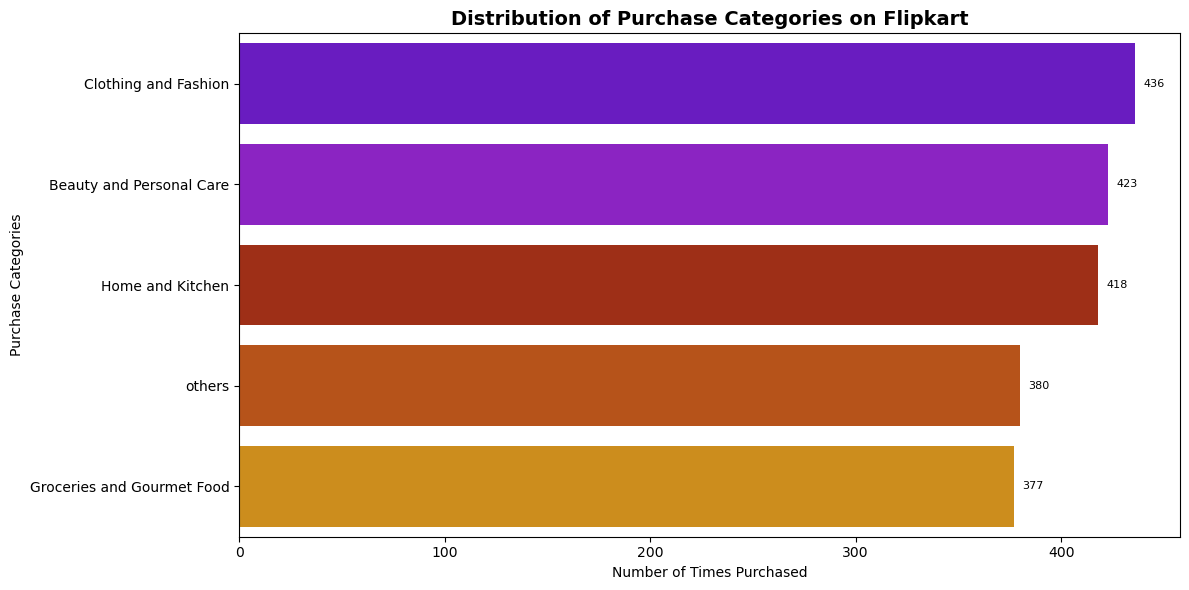

In [56]:
#Task-5- Visualization and Reporting 

#Sub_Task-1-Create Attractive Visulaisations:
#Bar_Chart for Purchase_Categories 

# Explode the Categories_List to get individual categories

categories_exploded = df['Categories_List'].explode()

category_counts = categories_exploded.value_counts().head(15)

plt.figure(figsize=(12, 6))
y=sns.barplot(y=category_counts.index, x=category_counts.values, palette='gnuplot', orient='h')
plt.title('Distribution of Purchase Categories on Flipkart', fontsize=14,fontweight='bold')
for container in y.containers:
    y.bar_label(container,padding=6,fontsize=8)
plt.xlabel('Number of Times Purchased')
plt.ylabel('Purchase Categories')
plt.tight_layout()
plt.savefig('Distribution of Purchase Categories.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_4668\3489117376.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,y='Browsing_Frequency',order=df['Browsing_Frequency'].value_counts().index,palette='viridis')


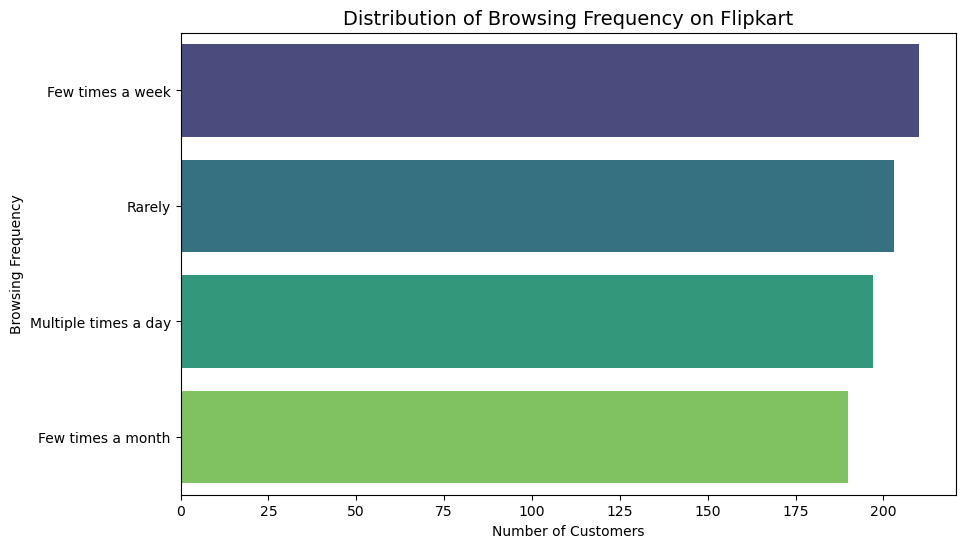

In [58]:
#Countplot-Browsing_Frequency
plt.figure(figsize=(10,6))
sns.countplot(data=df,y='Browsing_Frequency',order=df['Browsing_Frequency'].value_counts().index,palette='viridis')
plt.title('Distribution of Browsing Frequency on Flipkart', fontsize=14)
plt.xlabel('Number of Customers')
plt.ylabel('Browsing Frequency')
plt.savefig('Distribution of Browsing Frequency on Flipkart.png',dpi=300,bbox_inches='tight')
plt.show()


In [65]:
df['Shopping_Satisfaction_Tag']

0          Very Dissatisfied / Not at All Satisfied
1                    Satisfied / Somewhat Satisfied
2                    Satisfied / Somewhat Satisfied
3              Very Satisfied / Extremely Satisfied
4          Very Dissatisfied / Not at All Satisfied
                           ...                     
795    Neutral / Neither Satisfied nor Dissatisfied
796                  Satisfied / Somewhat Satisfied
797    Neutral / Neither Satisfied nor Dissatisfied
798                  Satisfied / Somewhat Satisfied
799            Dissatisfied / Somewhat Dissatisfied
Name: Shopping_Satisfaction_Tag, Length: 800, dtype: object

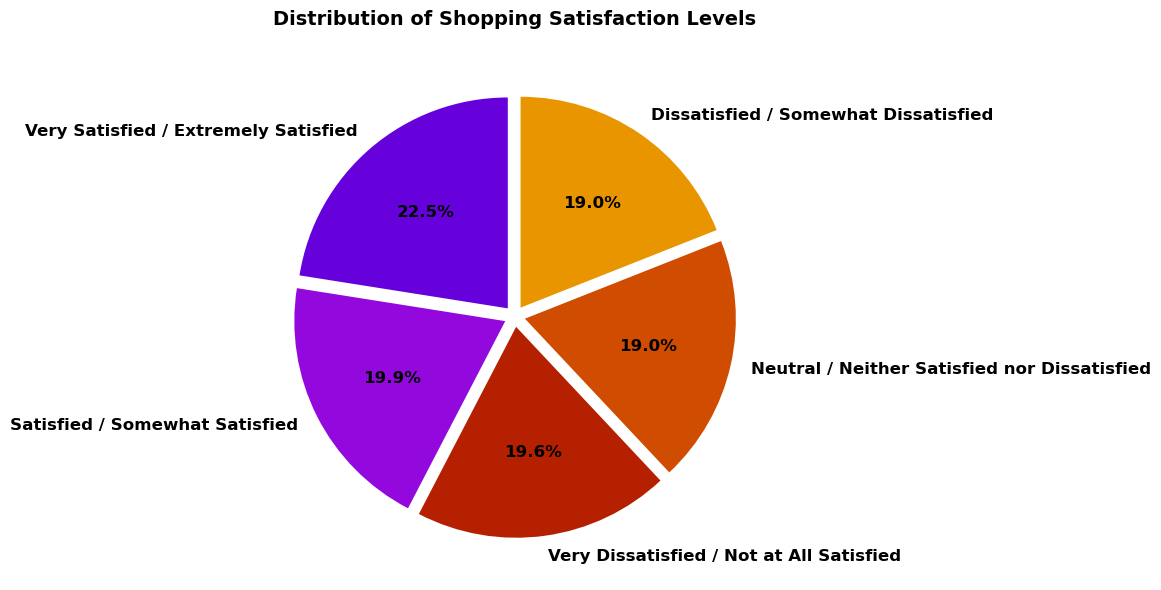

In [73]:
#Pie-Chart for Satisfaction levels

shop_sats_map={1:'Very Dissatisfied / Not at All Satisfied',2: 'Dissatisfied / Somewhat Dissatisfied',3: 'Neutral / Neither Satisfied nor Dissatisfied',
               4: 'Satisfied / Somewhat Satisfied',5:'Very Satisfied / Extremely Satisfied'} 

df['Shopping_Satisfaction_Tag']=df['Shopping_Satisfaction'].map(shop_sats_map)

satisfaction_counts = df['Shopping_Satisfaction_Tag'].value_counts()

plt.figure(figsize=(10, 8))
colors = sns.color_palette("gnuplot", len(satisfaction_counts))
plt.pie(satisfaction_counts,labels=satisfaction_counts.index,autopct='%1.1f%%',colors=colors,startangle=90,
        explode=[0.05] * len(satisfaction_counts),  
        textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'black'})

plt.title('Distribution of Shopping Satisfaction Levels', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('Shopping Satisfaction Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

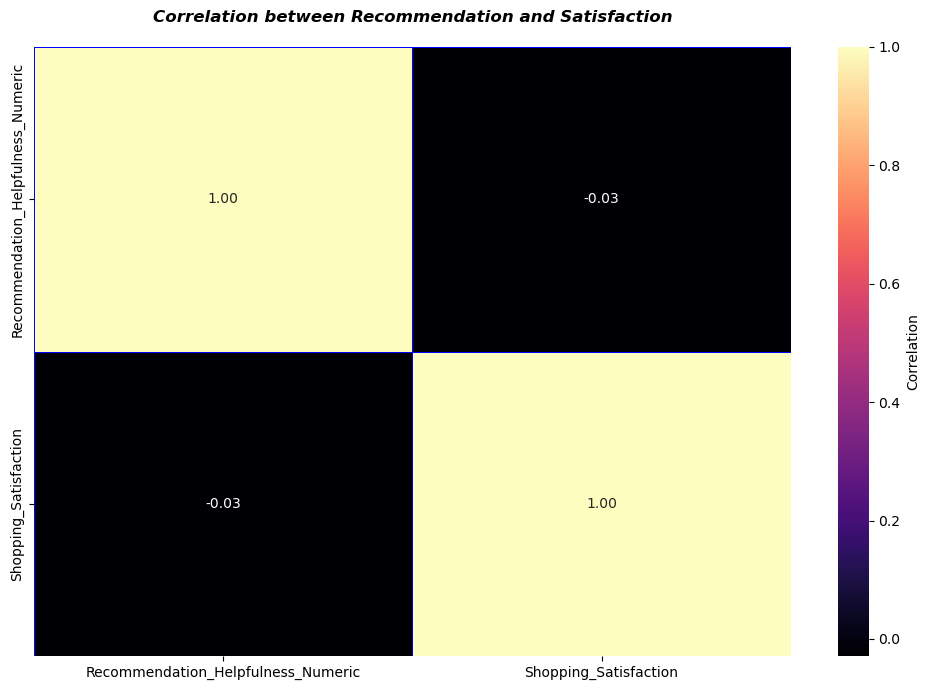

In [74]:
#Correlation between Recommendation Helpfulness and Shopping Satisfaction 
plt.figure(figsize=(10,7))
correlation_matrix = df[['Recommendation_Helpfulness_Numeric', 'Shopping_Satisfaction']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='magma', fmt='.2f', cbar=True, cbar_kws={'label': 'Correlation'}, linewidths=0.5, linecolor='Blue')
plt.title('Correlation between Recommendation and Satisfaction',fontsize=12,fontstyle='italic',fontweight='bold',pad=18)
plt.tight_layout()
plt.savefig('Correlation Plot Between Recommendation and Satisfaction',dpi=300,bbox_inches='tight')
plt.show()

In [76]:
#Sub_Task-3-Apriori Test to find top frequent pairs of products which are bought together

transactions = df['Categories_List'].tolist()

# Count single categories
item_counts = Counter()
for t in transactions:
    for item in t:
        item_counts[item] += 1

total_transactions = len(transactions)
min_support = 0.10

# Frequent single items
frequent_items = {item: count / total_transactions 
                  for item, count in item_counts.items() 
                  if count / total_transactions >= min_support}

print(f"Found {len(frequent_items)} frequent categories")

# Count pairs
pair_counts = Counter()
for t in transactions:
    for pair in combinations(sorted(t), 2):
        pair_counts[pair] += 1

# Build rules
rules = []
for (item1, item2), count in pair_counts.items():
    support = count / total_transactions
    if support >= min_support:
        conf1 = support / frequent_items[item1]
        conf2 = support / frequent_items[item2]
        rules.append({
            'Item1': item1,
            'Item2': item2,
            'Support': round(support, 3),
            'Confidence_Item1→Item2': round(conf1, 3),
            'Confidence_Item2→Item1': round(conf2, 3)
        })

if len(rules) == 0:
    print("No rules found.")
else:
    rules_df = pd.DataFrame(rules)
    rules_df = rules_df.sort_values('Support', ascending=False).reset_index(drop=True)
    print(f"\n Found {len(rules_df)} strong rules")
    print(rules_df.head(15))

Found 5 frequent categories

 Found 10 strong rules
                        Item1                       Item2  Support  \
0    Beauty and Personal Care        Clothing and Fashion    0.278   
1        Clothing and Fashion            Home and Kitchen    0.266   
2        Clothing and Fashion                      others    0.263   
3        Clothing and Fashion  Groceries and Gourmet Food    0.261   
4  Groceries and Gourmet Food            Home and Kitchen    0.254   
5    Beauty and Personal Care  Groceries and Gourmet Food    0.251   
6    Beauty and Personal Care            Home and Kitchen    0.246   
7    Beauty and Personal Care                      others    0.240   
8            Home and Kitchen                      others    0.234   
9  Groceries and Gourmet Food                      others    0.211   

   Confidence_Item1→Item2  Confidence_Item2→Item1  
0                   0.525                   0.509  
1                   0.489                   0.510  
2                   0

In [77]:
#Pivoting the 'Rules' to plot impactful visual
top_rules = rules_df.head(10).copy()   
pivot_support = top_rules.pivot(index='Item1', columns='Item2', values='Support')
pivot_support = pivot_support.fillna(0)
print(pivot_support)



Item2                       Clothing and Fashion  Groceries and Gourmet Food  \
Item1                                                                          
Beauty and Personal Care                   0.278                       0.251   
Clothing and Fashion                       0.000                       0.261   
Groceries and Gourmet Food                 0.000                       0.000   
Home and Kitchen                           0.000                       0.000   

Item2                       Home and Kitchen  others  
Item1                                                 
Beauty and Personal Care               0.246   0.240  
Clothing and Fashion                   0.266   0.263  
Groceries and Gourmet Food             0.254   0.211  
Home and Kitchen                       0.000   0.234  


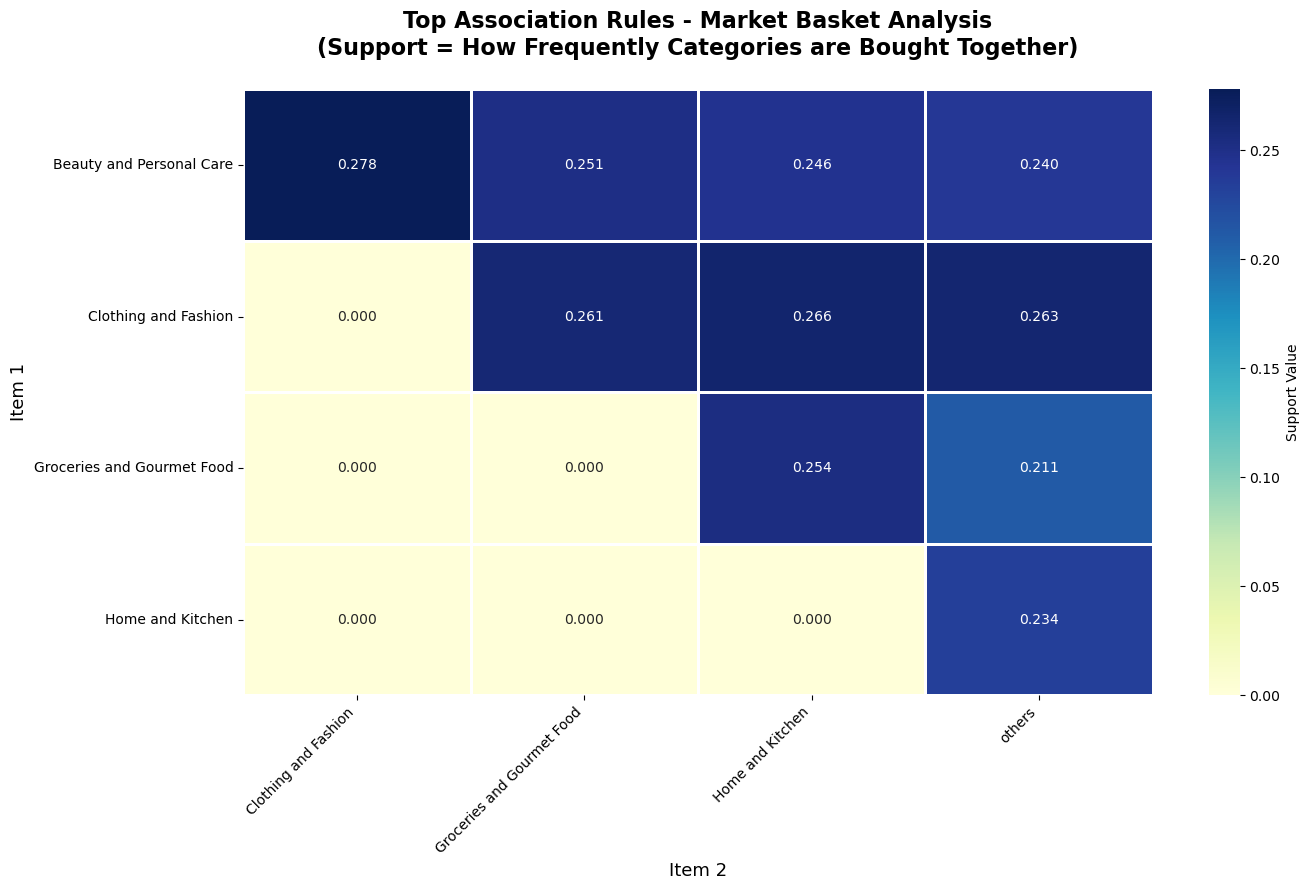

In [78]:
#heatmap
plt.figure(figsize=(14, 9))

ax = sns.heatmap(pivot_support,annot=True,fmt='.3f',cmap='YlGnBu',linewidths=0.8,linecolor='white',cbar_kws={'label': 'Support Value'})

plt.title('Top Association Rules - Market Basket Analysis\n(Support = How Frequently Categories are Bought Together)', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('Item 2', fontsize=13)
plt.ylabel('Item 1', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('Top Association Rules.png',dpi=300,bbox_inches='tight')
plt.show()

Market Basket Analysis Insights (Flipkart)-In Accordance with Apriori Algorithm

The heatmap clearly shows the strongest product affinities among Flipkart customers:

Key Observations:

Clothing and Fashion is the most central and frequently co-purchased category. It has strong associations with Groceries and Gourmet Food (0.

261), Home and Kitchen (0.266), and Beauty and Personal Care.

Beauty and Personal Care is the second strongest category, showing the highest support (0.278) when paired with Clothing and Fashion.

Groceries and Gourmet Food and Home and Kitchen also show meaningful co-occurrence (support 0.254 when bought together).

The “others” category appears frequently but is less insightful — we focus on the clear, actionable pairs.

Top 5 Strongest Cross-Category Pairs (Support):

Beauty and Personal Care + Clothing and Fashion → 0.278 (Strongest bundle)

Clothing and Fashion + Home and Kitchen → 0.266

Clothing and Fashion + Groceries and Gourmet Food → 0.261

Groceries and Gourmet Food + Home and Kitchen → 0.254

Beauty and Personal Care + Groceries and Gourmet Food → 0.251

Overall Insight:

Flipkart customers who buy Clothing and Fashion or Beauty and Personal Care have a very high tendency to also buy items from Groceries, Home & 

Kitchen, and vice versa. These four categories form the core of cross-purchasing behaviour.



Actionable Recommendations for Flipkart

1. Cross-Selling & Bundling (Highest Priority)

  Create “Frequently Bought Together” bundles:
  Clothing + Beauty products
  Clothing + Home & Kitchen items
  Beauty + Groceries

Offer combo discounts or “Buy Clothing, Get 15% off on Beauty” suggestions at checkout.

2. Improve Personalized Recommendations

The current recommendation engine should prioritize these high-support pairs.
When a customer adds Clothing to the cart, automatically recommend Beauty, Groceries, or Home & Kitchen products.
Expected impact: Increase average order value by 15–25%.

3. Targeted Promotions & Campaigns

Run category-specific campaigns:
“Fashion + Beauty Fest”
“Home Makeover with Groceries” bundles

Send personalized emails/SMS to customers who bought Clothing in the last 30 days with Beauty/Grocery offers.

4. Cart Recovery Strategy

For customers who abandon carts containing Clothing or Beauty, show instant offers on Home & Kitchen or Groceries to complete the purchase.

5. Inventory & Marketing Optimization

Stock more joint inventory of Clothing + Beauty and Clothing + Home & Kitchen.
Use these rules to decide homepage banners, search suggestions, and product page recommendations.

Expected Business Impact:

Higher cross-selling → increased Average Order Value (AOV)

Better personalization → higher customer satisfaction and repeat purchases

Reduced cart abandonment in key categories

Video Link:
https://www.loom.com/share/e8a0b1e41d3e4fa49eeeed7d4789591f